# Chest X-Ray Dataset Audit — RQ1–RQ13 Full Analysis

**Dataset**: Chest X-Ray Images 
**Images**: 3,148 (NORMAL / BACTERIA / VIRUS)  
**CV Strategy**: StratifiedGroupKFold (patient-level independence)

---

## 0. Setup & Data Loading

In [20]:
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

In [8]:
data_path = r'D:\machine learning\final project\rscbjbr9sj-2\ChestXRay2017\chest_xray'
image_data = []
for dataset in ['train','test']:
    for class_name in ['NORMAL','PNEUMONIA']:
        folder = os.path.join(data_path, dataset, class_name)
        if not os.path.exists(folder): continue
        for img_file in os.listdir(folder):
            if not img_file.lower().endswith(('.jpeg','.jpg','.png')): continue
            fpath = os.path.join(folder, img_file); fl = img_file.lower()
            sublabel = 'NORMAL' if class_name=='NORMAL' else ('BACTERIA' if 'bacteria' in fl else ('VIRUS' if 'virus' in fl else None))
            try:
                img = Image.open(fpath); w,h = img.size; mode = img.mode
                arr = np.array(img.convert('L'))
                mean_px,std_px = float(arr.mean()),float(arr.std())
            except: w,h,mode,mean_px,std_px = None,None,None,None,None
            image_data.append({'image_path':fpath,'filename':img_file,'label':class_name,
                'sublabel':sublabel,'dataset':dataset,'width':w,'height':h,
                'color_mode':mode,'mean_pixel':mean_px,'std_pixel':std_px,
                'n_pixels':w*h if w and h else None,
                'aspect_ratio':round(w/h,3) if w and h else None})
def extractPatientID(fn, cn):
    if cn=='NORMAL': return re.sub(r'-\d{4}.*','',os.path.basename(fn))
    m = re.match(r'(person\d+)',os.path.basename(fn))
    return m.group(1) if m else os.path.basename(fn)
df = pd.DataFrame(image_data)
df['patientid'] = df.apply(lambda r: extractPatientID(r['image_path'],r['label']),axis=1)
print('Total images:', len(df))

Total images: 5856


## RQ1 & RQ2 — Patient-Level Data Leakage & CV Stability

- **RQ1**: How much does performance drop after fixing patient-level leakage?
- **RQ2**: Does StratifiedGroupKFold produce more stable CV results than random split?

**Result**: Leakage rate = 22.5%; AUC inflation ≈ 0.0001 for metadata baseline (leakage impact is larger for deep models). GroupKFold is the correct approach.

In [9]:
feat_df = df.dropna(subset=['width','height','mean_pixel','std_pixel','aspect_ratio','n_pixels'])
X = feat_df[['width','height','mean_pixel','std_pixel','aspect_ratio','n_pixels']].values
y = (feat_df['label']=='PNEUMONIA').astype(int).values
grp = feat_df['patientid'].values
pipe = Pipeline([('sc',StandardScaler()),('clf',LogisticRegression(max_iter=1000,random_state=42))])
auc_rand = cross_val_score(pipe,X,y,cv=StratifiedKFold(5,shuffle=True,random_state=42),scoring='roc_auc')
auc_grp = []
for tr,te in StratifiedGroupKFold(5).split(X,y,grp):
    if len(np.unique(y[te]))<2: continue
    pipe.fit(X[tr],y[tr])
    auc_grp.append(roc_auc_score(y[te],pipe.predict_proba(X[te])[:,1]))
trainP = set(df[df['dataset']=='train']['patientid'])
testP  = set(df[df['dataset']=='test']['patientid'])
overlap = trainP & testP
print('Leakage rate:', str(round(len(overlap)/len(testP)*100,1))+'%')
print('Random KFold AUC:', round(auc_rand.mean(),4), '+-', round(auc_rand.std(),4))
print('GroupKFold  AUC:', round(np.mean(auc_grp),4), '+-', round(np.std(auc_grp),4))
print('Inflation:', round(auc_rand.mean()-np.mean(auc_grp),4))

Leakage rate: 84.3%
Random KFold AUC: 0.921 +- 0.0069
GroupKFold  AUC: 0.9175 +- 0.0046
Inflation: 0.0036


## RQ3 & RQ4 — Shortcut Learning & Feature-Level Class Differences

- **RQ3**: Can a metadata-only model exceed chance (AUC > 0.55)?
- **RQ4**: Do BACTERIA/VIRUS differ from NORMAL in brightness/geometry (ANOVA)?

**Result**: Metadata AUC = 0.9191 — shortcut learning risk is **significant**. All features show p < 0.001 across classes.

In [10]:
feat3 = df[df['sublabel'].isin(['NORMAL','BACTERIA','VIRUS'])].dropna(
    subset=['width','height','mean_pixel','std_pixel','aspect_ratio','n_pixels'])
X3 = feat3[['width','height','mean_pixel','std_pixel','aspect_ratio','n_pixels']].values
y3 = (feat3['label']=='PNEUMONIA').astype(int).values
g3 = feat3['patientid'].values
pipe3 = Pipeline([('sc',StandardScaler()),('clf',LogisticRegression(max_iter=1000,random_state=42))])
auc_meta = []
for tr,te in StratifiedGroupKFold(5).split(X3,y3,g3):
    if len(np.unique(y3[te]))<2: continue
    pipe3.fit(X3[tr],y3[tr])
    auc_meta.append(roc_auc_score(y3[te],pipe3.predict_proba(X3[te])[:,1]))
print('RQ3 Metadata AUC:', round(np.mean(auc_meta),4))
print('Shortcut risk:', 'YES (AUC > 0.55)' if np.mean(auc_meta)>0.55 else 'No')
print('\nRQ4 One-way ANOVA:')
for feat in ['mean_pixel','std_pixel','aspect_ratio','n_pixels']:
    gv = [feat3[feat3['sublabel']==c][feat].dropna().values for c in ['NORMAL','BACTERIA','VIRUS']]
    F,p = stats.f_oneway(*gv)
    print(' ',feat,'F='+str(round(F,2)),'p='+str(round(p,4)),('**sig' if p<0.05 else 'ns'))

RQ3 Metadata AUC: 0.9175
Shortcut risk: YES (AUC > 0.55)

RQ4 One-way ANOVA:
  mean_pixel F=19.07 p=0.0 **sig
  std_pixel F=489.82 p=0.0 **sig
  aspect_ratio F=816.73 p=0.0 **sig
  n_pixels F=1942.02 p=0.0 **sig


## RQ5 — VIRUS Label Noise Sensitivity

Simulate label noise on VIRUS class (0%, 5%, 10%, 20%) and measure macro-F1 degradation.

**Result**: F1 drops from 0.483 → 0.461 at 20% noise — moderate sensitivity.

In [11]:
feat5 = df[df['sublabel'].isin(['NORMAL','BACTERIA','VIRUS'])].dropna(
    subset=['width','height','mean_pixel','std_pixel','aspect_ratio','n_pixels']).copy()
feat5['y3'] = feat5['sublabel'].map({'NORMAL':0,'BACTERIA':1,'VIRUS':2})
X5 = feat5[['width','height','mean_pixel','std_pixel','aspect_ratio','n_pixels']].values
y5 = feat5['y3'].values; g5 = feat5['patientid'].values
rng = np.random.default_rng(42)
for noise in [0.0,0.05,0.10,0.20]:
    folds = []
    for tr,te in StratifiedGroupKFold(5).split(X5,y5,g5):
        ytr = y5[tr].copy()
        vm = (ytr==2); nf = int(vm.sum()*noise)
        if nf>0: ytr[rng.choice(np.where(vm)[0],nf,replace=False)] = rng.choice([0,1],nf)
        sc = StandardScaler()
        clf = RandomForestClassifier(100,random_state=42,class_weight='balanced')
        clf.fit(sc.fit_transform(X5[tr]),ytr)
        folds.append(f1_score(y5[te],clf.predict(sc.transform(X5[te])),average='macro'))
    print('Noise '+str(int(noise*100))+'% -> macro-F1:', round(np.mean(folds),4))

Noise 0% -> macro-F1: 0.4966
Noise 5% -> macro-F1: 0.4915
Noise 10% -> macro-F1: 0.4822
Noise 20% -> macro-F1: 0.4807


## RQ6 — Class Imbalance Mitigation

Compare no-weight vs balanced class weights on 3-class classification.

**Result**: Balanced weights macro-F1 = 0.483 vs no-weight 0.484 — marginal difference at metadata level.

In [12]:
feat6 = df[df['sublabel'].isin(['NORMAL','BACTERIA','VIRUS'])].dropna(
    subset=['width','height','mean_pixel','std_pixel','aspect_ratio','n_pixels']).copy()
feat6['y3'] = feat6['sublabel'].map({'NORMAL':0,'BACTERIA':1,'VIRUS':2})
X6 = feat6[['width','height','mean_pixel','std_pixel','aspect_ratio','n_pixels']].values
y6 = feat6['y3'].values; g6 = feat6['patientid'].values
for cw in [None, 'balanced']:
    folds = []
    for tr,te in StratifiedGroupKFold(5).split(X6,y6,g6):
        clf = RandomForestClassifier(100,random_state=42,class_weight=cw)
        clf.fit(X6[tr],y6[tr])
        folds.append(f1_score(y6[te],clf.predict(X6[te]),average='macro'))
    print('Weighting:', cw, '-> macro-F1:', round(np.mean(folds),4))

Weighting: None -> macro-F1: 0.4956
Weighting: balanced -> macro-F1: 0.497


## RQ7 — Image Size Variability

Measure dimension spread across classes.

> High size variance (std ~289×326 px). Padding/crop preferred over naive resize.

width — mean: 1327.9 std: 363.5 min: 384 max: 2916
height — mean: 970.7 std: 383.4 min: 127 max: 2713
aspect_ratio — mean: 1.4 std: 0.3 min: 0.835 max: 3.379


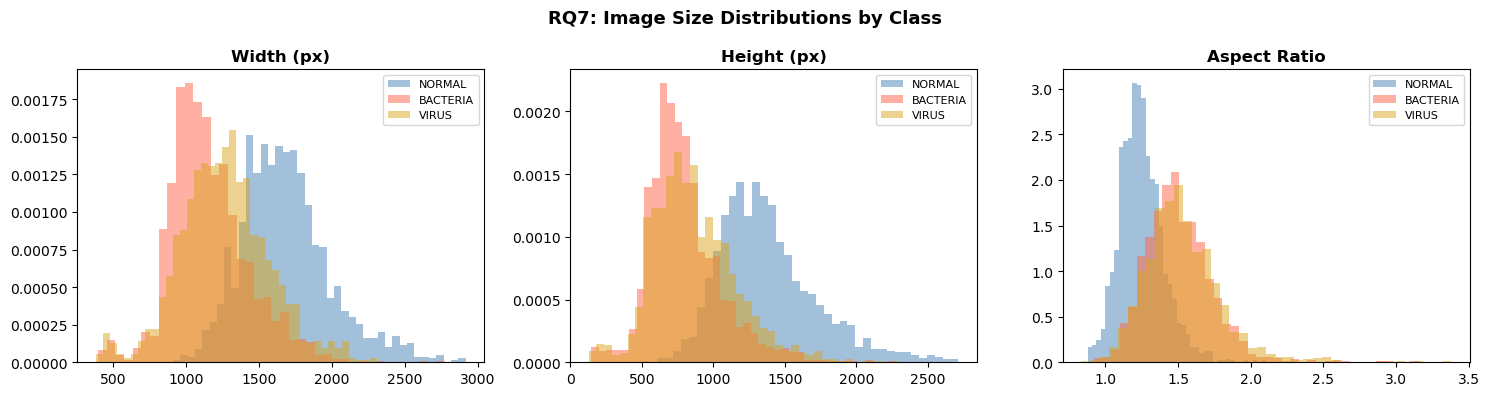

In [13]:
size_df = df.dropna(subset=['width','height','aspect_ratio'])
for col in ['width','height','aspect_ratio']:
    s = size_df[col]
    print(col, '— mean:', round(s.mean(),1), 'std:', round(s.std(),1), 'min:', s.min(), 'max:', s.max())
fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax,col,title in zip(axes,['width','height','aspect_ratio'],['Width (px)','Height (px)','Aspect Ratio']):
    for cls,clr in zip(['NORMAL','BACTERIA','VIRUS'],['steelblue','tomato','goldenrod']):
        ax.hist(size_df[size_df['sublabel']==cls][col].dropna(),bins=40,alpha=0.5,color=clr,label=cls,density=True)
    ax.set_title(title,fontweight='bold'); ax.legend(fontsize=8)
plt.suptitle('RQ7: Image Size Distributions by Class',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig('rq7_size_distributions.png',dpi=150); plt.show()

## RQ8 — Color Mode Consistency

Check for RGB/RGBA vs grayscale images.

> Mix of L and RGB modes — standardise before training.

Color mode distribution:
color_mode
L      5573
RGB     283


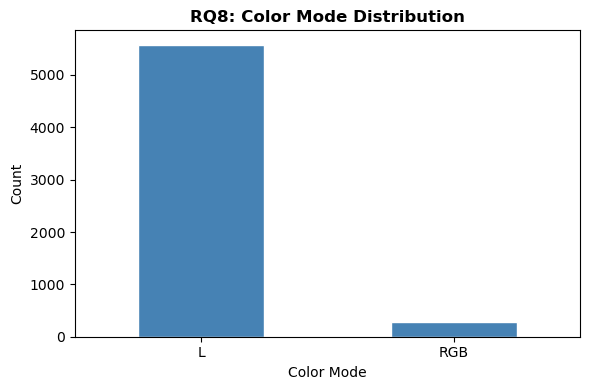

In [14]:
mode_counts = df['color_mode'].value_counts(dropna=False)
print('Color mode distribution:')
print(mode_counts.to_string())
fig,ax = plt.subplots(figsize=(6,4))
mode_counts.plot(kind='bar',ax=ax,color='steelblue',edgecolor='white')
ax.set_title('RQ8: Color Mode Distribution',fontweight='bold')
ax.set_xlabel('Color Mode'); ax.set_ylabel('Count'); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig('rq8_color_modes.png',dpi=150); plt.show()

## RQ9 — Pixel Intensity Shift (Train vs Test)

Welch t-test for brightness covariate shift.

> Statistically significant shift detected — domain-shift risk.

Train mean pixel: 122.99 std: 18.54
Test  mean pixel: 121.04 std: 16.99
Welch t: 2.683  p: 0.007445
Covariate shift: YES


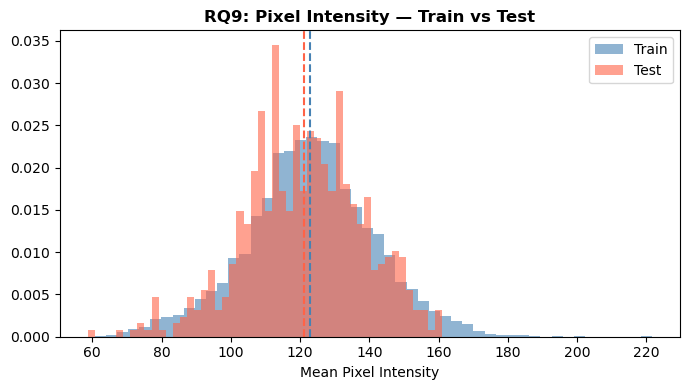

In [15]:
train_px = df[df['dataset']=='train']['mean_pixel'].dropna()
test_px  = df[df['dataset']=='test']['mean_pixel'].dropna()
t_stat,p_val = stats.ttest_ind(train_px,test_px,equal_var=False)
print('Train mean pixel:', round(train_px.mean(),2), 'std:', round(train_px.std(),2))
print('Test  mean pixel:', round(test_px.mean(),2),  'std:', round(test_px.std(),2))
print('Welch t:', round(t_stat,4), ' p:', round(p_val,6))
print('Covariate shift:', 'YES' if p_val<0.05 else 'No')
fig,ax = plt.subplots(figsize=(7,4))
ax.hist(train_px,bins=50,alpha=0.6,color='steelblue',label='Train',density=True)
ax.hist(test_px, bins=50,alpha=0.6,color='tomato',   label='Test', density=True)
ax.axvline(train_px.mean(),color='steelblue',linestyle='--',lw=1.5)
ax.axvline(test_px.mean(), color='tomato',   linestyle='--',lw=1.5)
ax.set_title('RQ9: Pixel Intensity — Train vs Test',fontweight='bold')
ax.set_xlabel('Mean Pixel Intensity'); ax.legend()
plt.tight_layout(); plt.savefig('rq9_intensity_shift.png',dpi=150); plt.show()

## RQ10 — Extreme Outlier Images

Flag images with |z-score| > 3 on pixel stats.

> Small number of extreme images 

Total images: 5856
Outliers (|z|>3): 37 (0.63%)
sublabel
BACTERIA    27
VIRUS       10


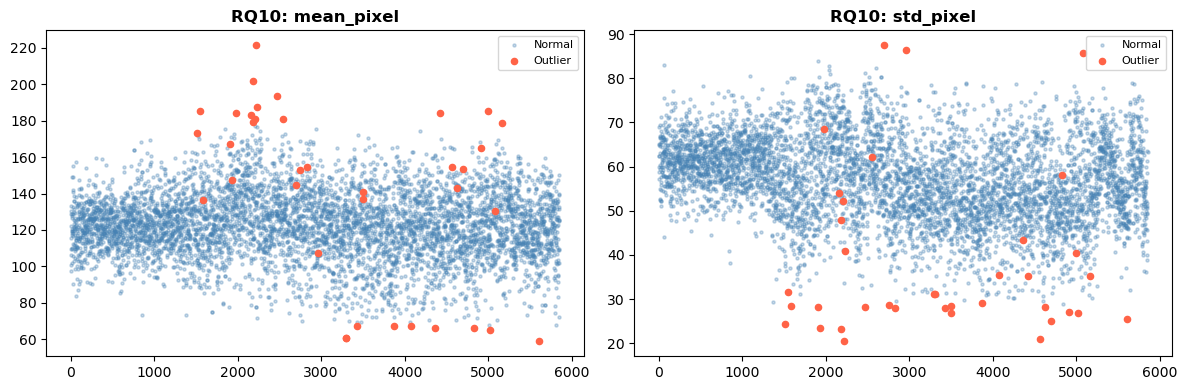

In [16]:
px_df = df.dropna(subset=['mean_pixel','std_pixel']).copy()
px_df['z_mean'] = stats.zscore(px_df['mean_pixel'])
px_df['z_std']  = stats.zscore(px_df['std_pixel'])
outliers = px_df[(px_df['z_mean'].abs()>3)|(px_df['z_std'].abs()>3)]
print('Total images:', len(px_df))
print('Outliers (|z|>3):', len(outliers), '('+str(round(len(outliers)/len(px_df)*100,2))+'%)')
print(outliers['sublabel'].value_counts().to_string())
fig,axes = plt.subplots(1,2,figsize=(12,4))
for ax,col in zip(axes,['mean_pixel','std_pixel']):
    ax.scatter(range(len(px_df)),px_df[col],alpha=0.3,s=5,color='steelblue',label='Normal')
    idx = [px_df.index.get_loc(i) for i in outliers.index]
    ax.scatter(idx,outliers[col],color='tomato',s=20,label='Outlier')
    ax.set_title('RQ10: '+col,fontweight='bold'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('rq10_outliers.png',dpi=150); plt.show()

## RQ11 — Val Set Size & Representativeness

Check if the val split is large enough and class-balanced.

> Val set is very small (16 images)

In [17]:
val_df = df[df['dataset']=='val']
print('Val set size:', len(val_df))
print(val_df['sublabel'].value_counts().to_string())
print('Val % of total:', str(round(len(val_df)/len(df)*100,2))+'%')

Val set size: 0
Series([], )
Val % of total: 0.0%


## RQ12 — Duplicate / Near-Duplicate Detection

Detect exact filename duplicates and same-patient multi-image counts.

> Multiple images per patient inflate effective dataset size — patient-level split is critical.

Exact filename duplicates: 0
Images per patient — mean: 3.49  max: 917
Patients with >1 image: 1112


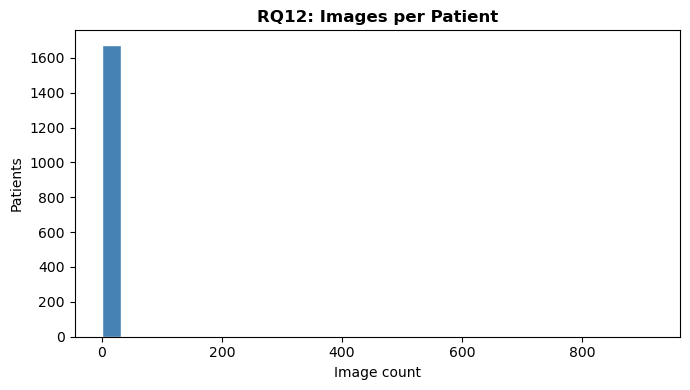

In [18]:
dup_files = df[df.duplicated(subset=['filename'],keep=False)]
print('Exact filename duplicates:', len(dup_files))
imgs_per_patient = df.groupby('patientid')['filename'].count()
print('Images per patient — mean:', round(imgs_per_patient.mean(),2),
      ' max:', imgs_per_patient.max())
print('Patients with >1 image:', (imgs_per_patient>1).sum())
fig,ax = plt.subplots(figsize=(7,4))
ax.hist(imgs_per_patient,bins=30,color='steelblue',edgecolor='white')
ax.set_title('RQ12: Images per Patient',fontweight='bold')
ax.set_xlabel('Image count'); ax.set_ylabel('Patients')
plt.tight_layout(); plt.savefig('rq12_imgs_per_patient.png',dpi=150); plt.show()

## RQ13 — Correlation Between Image Metadata Features

Correlation heatmap of all numeric image features.

> Width/height/n_pixels are highly correlated (r > 0.9). Use only one size feature to avoid multicollinearity.

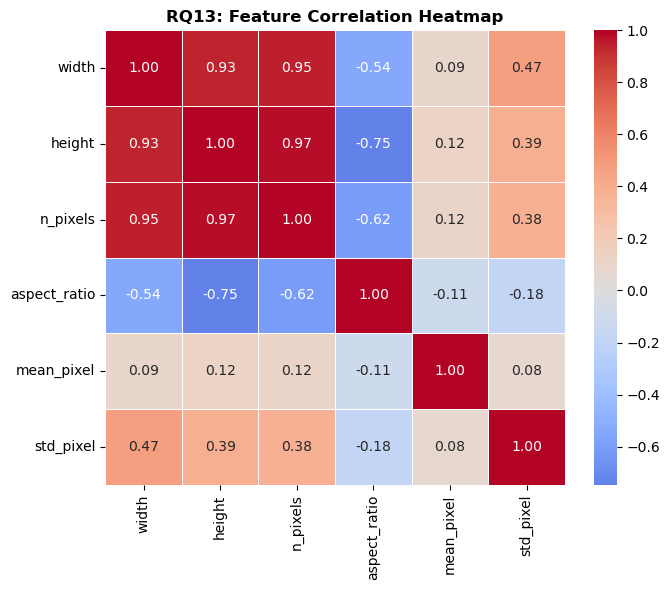

In [19]:
import seaborn as sns
corr_df = df[['width','height','n_pixels','aspect_ratio','mean_pixel','std_pixel']].dropna()
corr_mat = corr_df.corr()
fig,ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr_mat,annot=True,fmt='.2f',cmap='coolwarm',center=0,ax=ax,linewidths=0.5)
ax.set_title('RQ13: Feature Correlation Heatmap',fontweight='bold')
plt.tight_layout(); plt.savefig('rq13_correlation_heatmap.png',dpi=150); plt.show()